# Synthetic Data Generation

Generate synthetic data with the generators listed below
Based on the Wisconsin Breast Cancer Dataset (WBCD)

In [1]:
import sys  # standard library

sys.path.append("..")
import pandas as pd  # 3rd party packages

import config  # local packages
from generators.dataSynthesizer import DataSynthesizerGenerator
from generators.smote import SmoteGenerator
from generators.synthpop_generator import SynthpopGenerator

## Load the real WBCD dataset

In [2]:
df_real = pd.read_csv("../data/" + config.WBCD_DATASET_FILENAME)
df_real = df_real.drop(columns="Sample_code_number")
df_real["Class"] = (df_real["Class"] / 2 - 1).astype(
    int
)  # Class 0 or 1 instead of 2 and 4
df_real.shape

(683, 10)

In [3]:
df_real.head()

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


## Create the metadata dictionary

### The continuous and categorical variables need to be specified, as well as the variable to predict for the future learning task (used by SMOTE)

In [4]:
metadata = {
    "continuous": [
        "Clump_Thickness",
        "Uniformity_of_Cell_Size",
        "Uniformity_of_Cell_Shape",
        "Marginal_Adhesion",
        "Single_Epithelial_Cell_Size",
        "Bland_Chromatin",
        "Normal_Nucleoli",
        "Mitoses",
        "Bare_Nuclei",
    ],
    "categorical": ["Class"],
    "variable_to_predict": "Class",
}

## Choose the generator

In [5]:
generator = "synthpop_ordered"  # to choose among this list: ["synthpop", "synthpop_ordered", "smote", "datasynthesizer"]

### Synthpop

In [6]:
if generator == "synthpop":
    gen = SynthpopGenerator(
        df=df_real,
        metadata=metadata,
        random_state=66,  # for reproducibility, can be set to None
        generator_filepath=None,  # to load an existing generator,
        variables_order=None,  # use the dataframe columns order by default
    )

In [7]:
if generator == "synthpop_ordered":
    variables_order = [
        "Normal_Nucleoli",
        "Class",
        "Clump_Thickness",
        "Bare_Nuclei",
        "Bland_Chromatin",
        "Single_Epithelial_Cell_Size",
        "Mitoses",
        "Uniformity_of_Cell_Size",
        "Uniformity_of_Cell_Shape",
        "Marginal_Adhesion",
    ]
    gen = SynthpopGenerator(
        df=df_real,
        metadata=metadata,
        random_state=66,  # for reproducibility, can be set to None
        generator_filepath=None,  # to load an existing generator,
        variables_order=variables_order,  # can be found by searching the best hyperparameters
    )

### SMOTE

In [8]:
if generator == "smote":
    gen = SmoteGenerator(
        df=df_real,
        metadata=metadata,
        random_state=66,  # for reproducibility, can be set to None
        generator_filepath=None,  # to load an existing generator,
        k_neighbors=None,  # cannot be found by searching the best hyperparameters yet, set to 5 by default
    )

### Datasynthesizer

In [9]:
if generator == "datasynthesizer":
    gen = DataSynthesizerGenerator(
        df=df_real,
        metadata=metadata,
        random_state=66,  # for reproducibility, can be set to None
        generator_filepath=None,  # to load an existing generator
        candidate_keys=None,  # the identifiers
        epsilon=0,  # for the differential privacy
        degree=2,  # the maximal number of parents for the bayesian network
    )

## Fit the generator to the real data

In [10]:
gen.preprocess()
gen.fit(save_path="../results/generators")  # the path should exist

## Display the fitted generator

In [11]:
gen.display()

Constructed sequential trees:
   Normal_Nucleoli has parents []
   Class has parents ['Normal_Nucleoli']
   Clump_Thickness has parents ['Normal_Nucleoli', 'Class']
   Bare_Nuclei has parents ['Normal_Nucleoli', 'Class', 'Clump_Thickness']
   Bland_Chromatin has parents ['Normal_Nucleoli', 'Class', 'Clump_Thickness', 'Bare_Nuclei']
   Single_Epithelial_Cell_Size has parents ['Normal_Nucleoli', 'Class', 'Clump_Thickness', 'Bare_Nuclei', 'Bland_Chromatin']
   Mitoses has parents ['Normal_Nucleoli', 'Class', 'Clump_Thickness', 'Bare_Nuclei', 'Bland_Chromatin', 'Single_Epithelial_Cell_Size']
   Uniformity_of_Cell_Size has parents ['Normal_Nucleoli', 'Class', 'Clump_Thickness', 'Bare_Nuclei', 'Bland_Chromatin', 'Single_Epithelial_Cell_Size', 'Mitoses']
   Uniformity_of_Cell_Shape has parents ['Normal_Nucleoli', 'Class', 'Clump_Thickness', 'Bare_Nuclei', 'Bland_Chromatin', 'Single_Epithelial_Cell_Size', 'Mitoses', 'Uniformity_of_Cell_Size']
   Marginal_Adhesion has parents ['Normal_Nucleoli'

## Generate the synthetic data

In [12]:
df_synth = gen.sample(
    save_path="../results/data",  # the path should exist
    num_samples=len(
        df_real
    ),  # can be different from the real data, but for computing the utility metrics should be the same
)

In [13]:
df_synth.head()

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,10,10,7,3,10,1,8,8,10,1
2,1,1,1,1,2,1,2,1,1,0
3,1,1,1,1,2,1,3,1,1,0
4,8,1,4,3,2,2,2,2,1,0


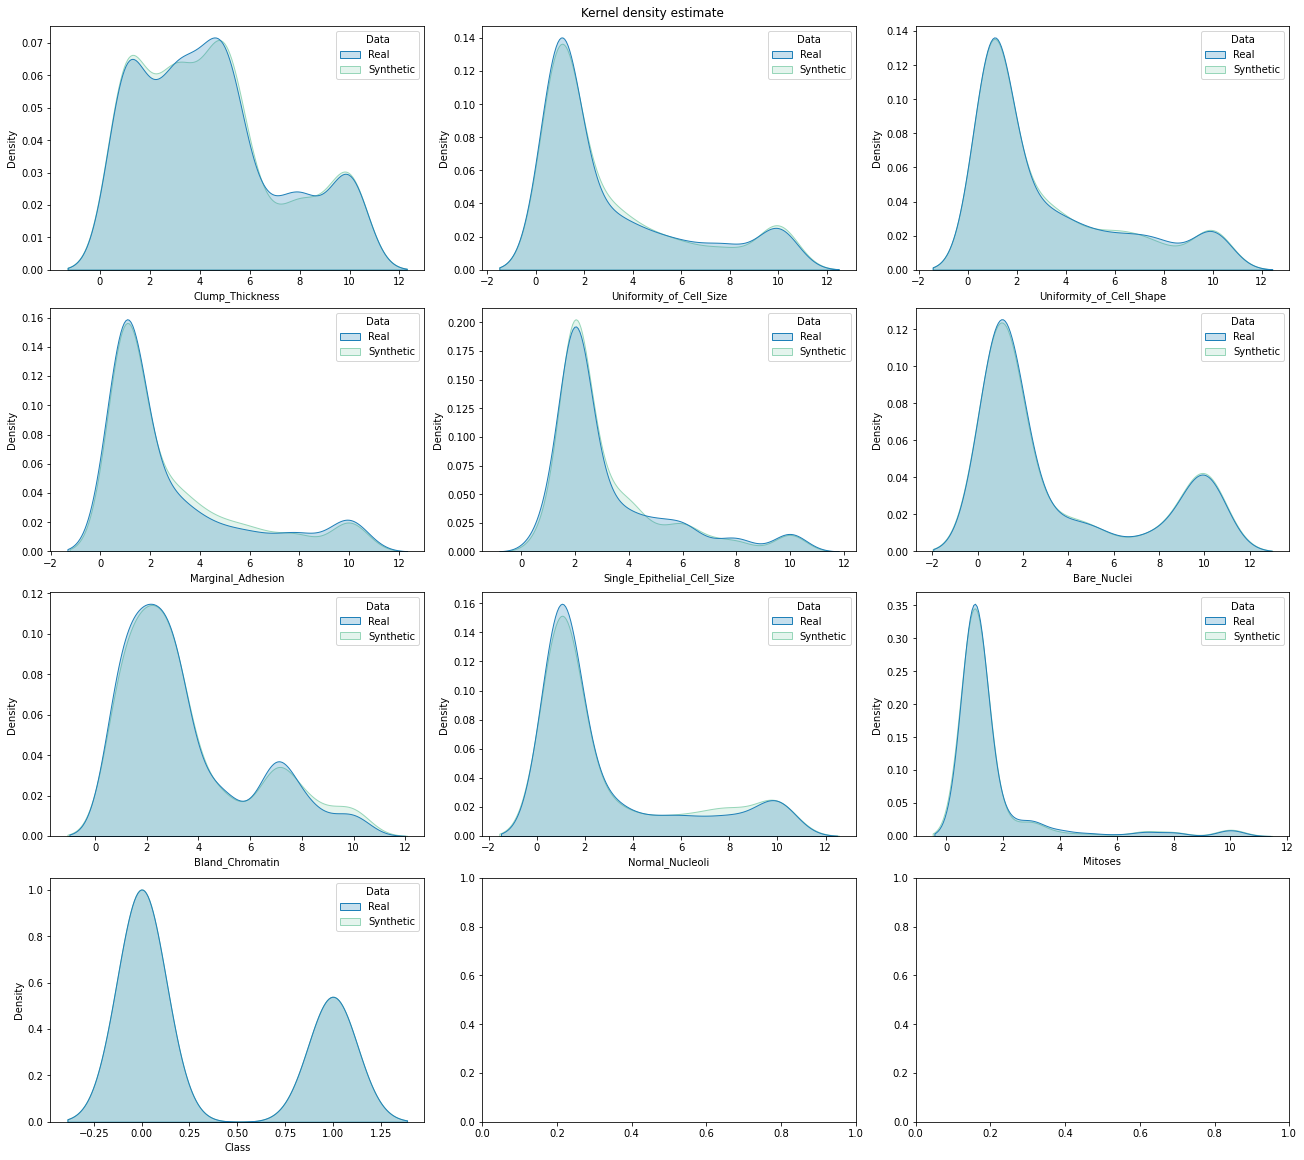

In [14]:
import matplotlib.pyplot as plt

import utils.draw

fig, axes = plt.subplots(  # manually set number of cols/rows
    nrows=4, ncols=3, squeeze=0, figsize=(18, 16), layout="constrained"
)
axes = axes.reshape(-1)
utils.draw.kde_plot_hue_plot_per_col(
    df=df_real,
    df_nested=df_synth,
    original_name="Real",
    nested_name="Synthetic",
    hue_name="Data",
    title="Kernel density estimate",
    axes=axes,
)